In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

plt.style.use('dark_background')
os.makedirs('charts', exist_ok=True)

matches = pd.read_csv('matches_clean.csv')
deliveries = pd.read_csv('deliveries_clean.csv')

print("Data loaded for PCA")

Data loaded for PCA


In [9]:
# Create a comprehensive stats table per batter
batting_stats = deliveries.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('batsman_runs', 'count'),
    fours=('batsman_runs', lambda x: (x == 4).sum()),
    sixes=('batsman_runs', lambda x: (x == 6).sum()),
    dismissals=('is_wicket', 'sum')
).reset_index()

# Filter for players with meaningful sample size
batting_stats = batting_stats[batting_stats['balls_faced'] >= 300]

# Derived features
batting_stats['strike_rate'] = (batting_stats['total_runs'] / batting_stats['balls_faced']) * 100
batting_stats['boundary_pct'] = ((batting_stats['fours'] + batting_stats['sixes']) / batting_stats['balls_faced']) * 100
batting_stats['avg'] = batting_stats['total_runs'] / batting_stats['dismissals'].replace(0, 1)
batting_stats['six_ratio'] = batting_stats['sixes'] / (batting_stats['fours'] + batting_stats['sixes']).replace(0, 1)

print(f"Players with 300+ balls faced: {len(batting_stats)}")
print(batting_stats.head())

Players with 300+ balls faced: 173
            batter  total_runs  balls_faced  fours  sixes  dismissals  \
1         A Badoni         634          505     46     24          26   
10        A Mishra         381          440     31      5          31   
17       A Symonds         974          781     74     41          26   
30  AB de Villiers        5181         3487    414    253         125   
32    AC Gilchrist        2069         1555    239     92          76   

    strike_rate  boundary_pct        avg  six_ratio  
1    125.544554     13.861386  24.384615   0.342857  
10    86.590909      8.181818  12.290323   0.138889  
17   124.711908     14.724712  37.461538   0.356522  
30   148.580442     19.128190  41.448000   0.379310  
32   133.054662     21.286174  27.223684   0.277946  


In [3]:
# Select numeric features for PCA
features = ['total_runs', 'strike_rate', 'boundary_pct', 'avg', 'six_ratio']
X = batting_stats[features].values

# Standardize — PCA is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized")
print(f"Shape: {X_scaled.shape}")
print(f"Mean of each feature (should be ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"Std of each feature (should be ~1): {X_scaled.std(axis=0).round(2)}")

Features standardized
Shape: (173, 5)
Mean of each feature (should be ~0): [ 0.  0.  0. -0. -0.]
Std of each feature (should be ~1): [1. 1. 1. 1. 1.]


In [4]:
# Apply PCA - keep all components first to see explained variance
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance by Each Component:")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {var*100:.2f}% (Cumulative: {cum*100:.2f}%)")

print()
print("Eigenvalues (variance explained by each PC):")
print(pca.explained_variance_)

Explained Variance by Each Component:
  PC1: 49.84% (Cumulative: 49.84%)
  PC2: 26.44% (Cumulative: 76.28%)
  PC3: 12.92% (Cumulative: 89.20%)
  PC4: 9.53% (Cumulative: 98.72%)
  PC5: 1.28% (Cumulative: 100.00%)

Eigenvalues (variance explained by each PC):
[2.50637652 1.32958942 0.6498906  0.47902096 0.06419227]


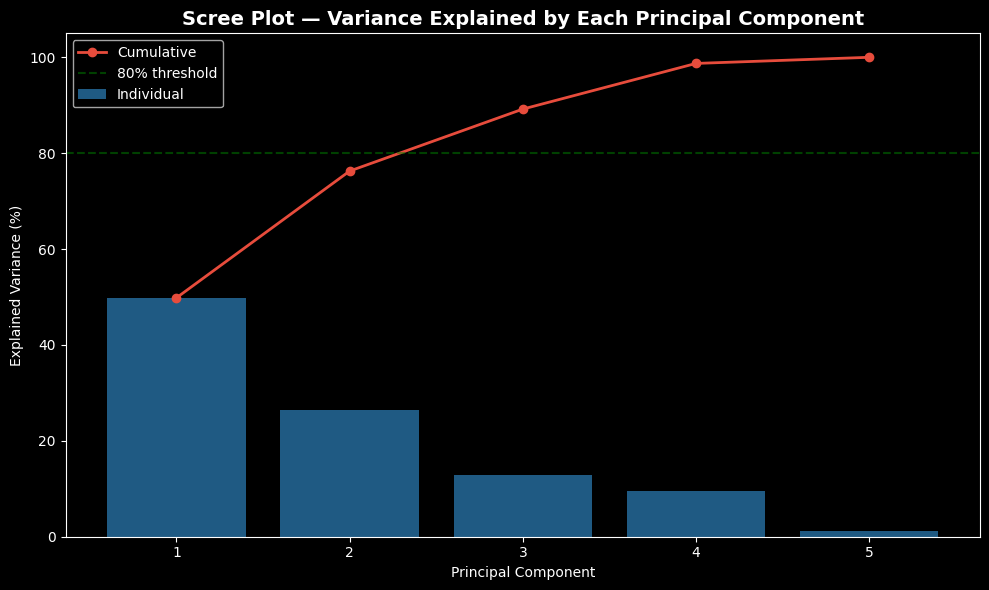

In [5]:
plt.figure(figsize=(10, 6))
components = range(1, len(explained_var) + 1)

plt.bar(components, explained_var * 100, alpha=0.6, color='#3498db', label='Individual')
plt.plot(components, cumulative_var * 100, 'o-', color='#e74c3c', linewidth=2, label='Cumulative')

plt.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot — Variance Explained by Each Principal Component', fontsize=14, fontweight='bold')
plt.xticks(components)
plt.legend()
plt.tight_layout()
plt.savefig('charts/18_scree_plot.png', dpi=150)
plt.show()

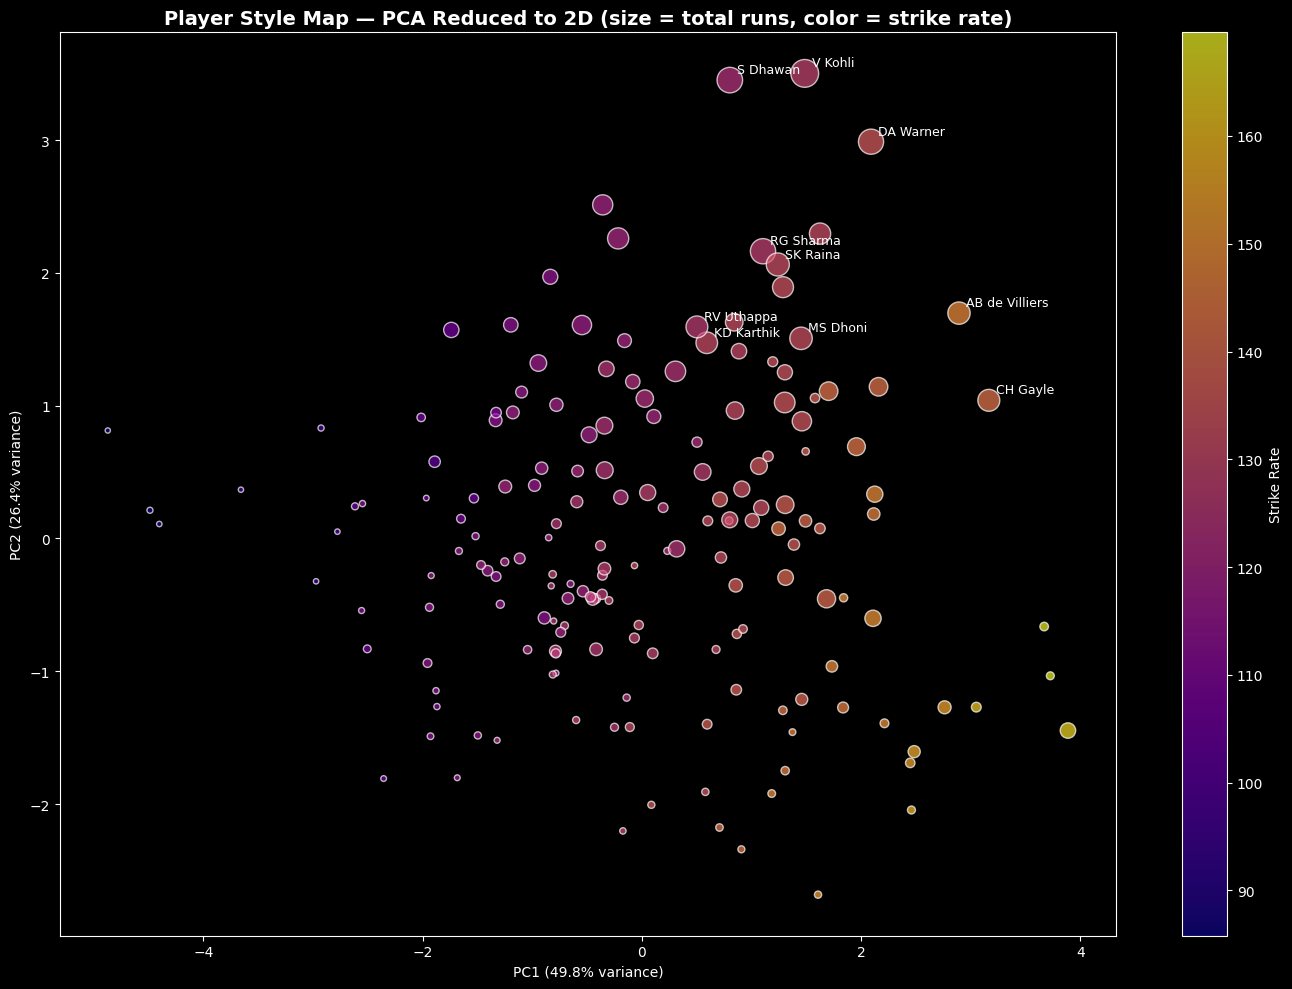

In [6]:
# Reduce to 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

batting_stats['PC1'] = X_pca_2d[:, 0]
batting_stats['PC2'] = X_pca_2d[:, 1]

plt.figure(figsize=(14, 10))
plt.scatter(batting_stats['PC1'], batting_stats['PC2'], 
            s=batting_stats['total_runs']/20, 
            c=batting_stats['strike_rate'], 
            cmap='plasma', alpha=0.7, edgecolors='white')

# Label top run scorers
top_players = batting_stats.nlargest(10, 'total_runs')
for _, row in top_players.iterrows():
    plt.annotate(row['batter'], (row['PC1'], row['PC2']), 
                 fontsize=9, color='white',
                 xytext=(5, 5), textcoords='offset points')

plt.colorbar(label='Strike Rate')
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.title('Player Style Map — PCA Reduced to 2D (size = total runs, color = strike rate)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/19_pca_player_map.png', dpi=150)
plt.show()

Feature Loadings (contribution to each PC):
                   PC1       PC2
total_runs    0.263154  0.636785
strike_rate   0.598225 -0.212396
boundary_pct  0.547785 -0.098656
avg           0.405784  0.482366
six_ratio     0.328857 -0.554061



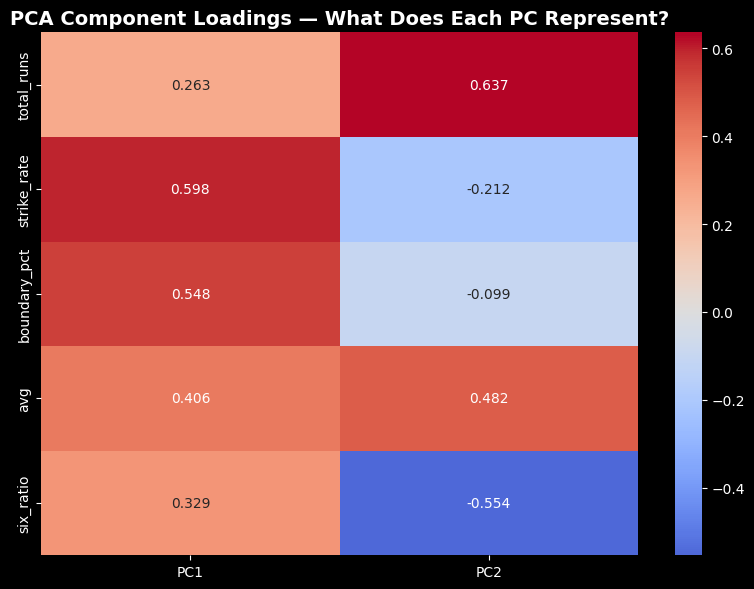


Interpretation:
PC1 is most influenced by: strike_rate (loading: 0.598)
PC2 is most influenced by: total_runs (loading: 0.637)


In [7]:
# Loadings tell us how much each original feature contributes to each PC
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print("Feature Loadings (contribution to each PC):")
print(loadings)
print()

# Visualize as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('PCA Component Loadings — What Does Each PC Represent?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/20_pca_loadings.png', dpi=150)
plt.show()

print("\nInterpretation:")
print(f"PC1 is most influenced by: {loadings['PC1'].abs().idxmax()} (loading: {loadings['PC1'].abs().max():.3f})")
print(f"PC2 is most influenced by: {loadings['PC2'].abs().idxmax()} (loading: {loadings['PC2'].abs().max():.3f})")

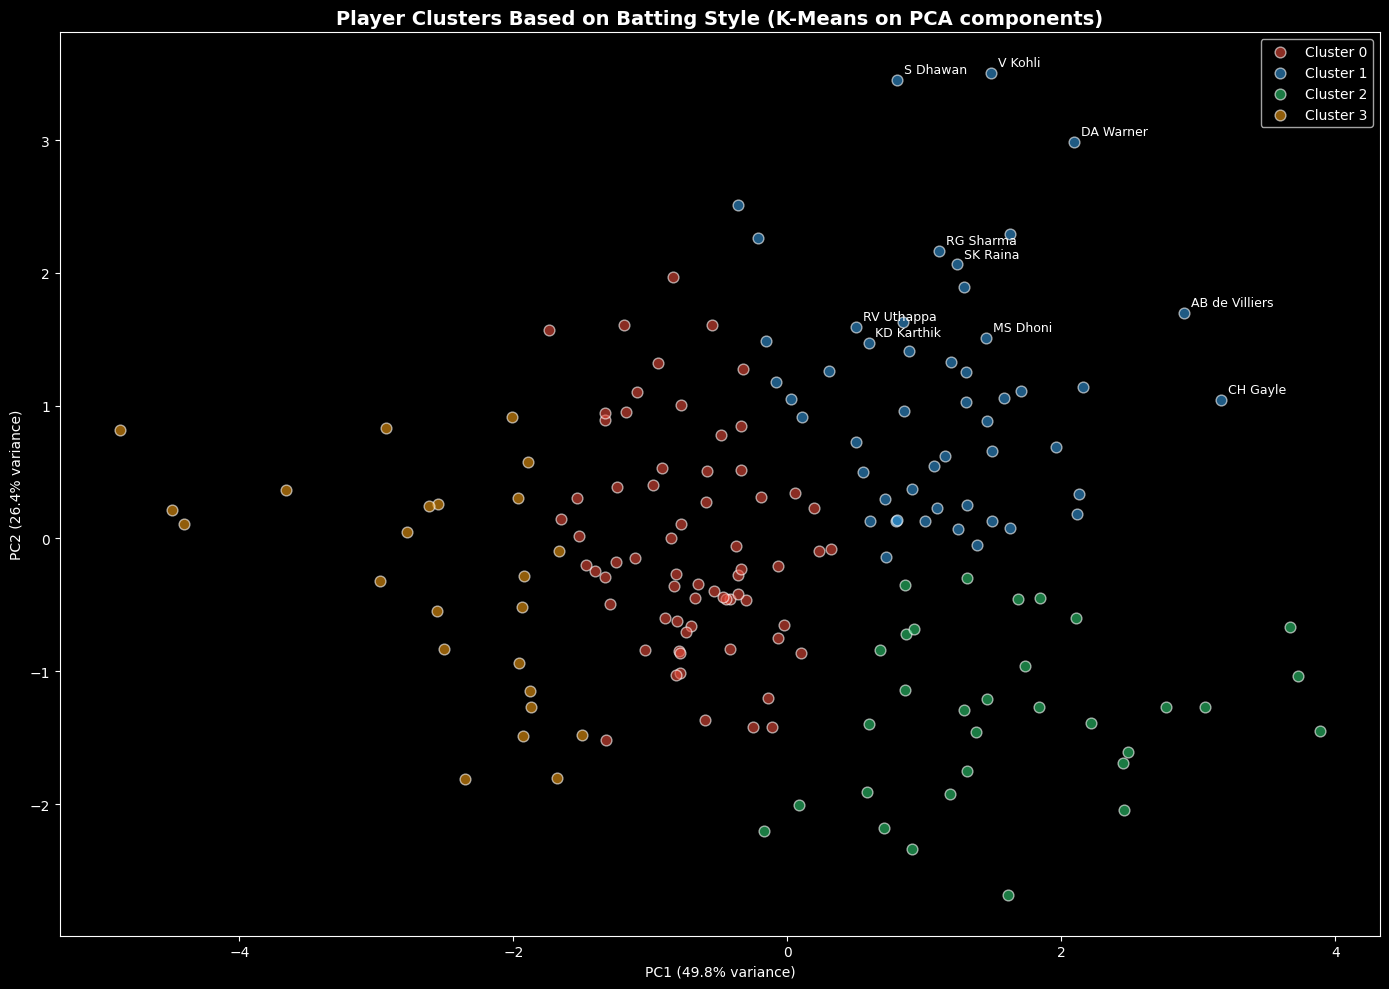


Cluster Profiles (average stats per cluster):
          total_runs  strike_rate  boundary_pct        avg  six_ratio
cluster                                                              
0        1297.328358   121.531129     15.167521  24.518787   0.284825
1        3188.980000   133.028160     18.145148  34.326263   0.291880
2        1131.750000   146.482584     20.082962  26.173393   0.446630
3         477.083333   105.601774     11.958324  17.126979   0.239807


In [8]:
from sklearn.cluster import KMeans

# Use PCA components for clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
batting_stats['cluster'] = kmeans.fit_predict(X_pca_2d)

plt.figure(figsize=(14, 10))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for cluster_id in range(4):
    cluster_data = batting_stats[batting_stats['cluster'] == cluster_id]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], 
                label=f'Cluster {cluster_id}', 
                color=colors[cluster_id], alpha=0.6, s=60, edgecolors='white')

# Label top players
for _, row in top_players.iterrows():
    plt.annotate(row['batter'], (row['PC1'], row['PC2']), 
                 fontsize=9, color='white',
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.title('Player Clusters Based on Batting Style (K-Means on PCA components)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('charts/21_player_clusters.png', dpi=150)
plt.show()

# Describe each cluster
print("\nCluster Profiles (average stats per cluster):")
cluster_profile = batting_stats.groupby('cluster')[features].mean()
print(cluster_profile)